In [1]:
import os, time, datetime, sys
import numpy as np
import pandas as pd
from collections import Counter
from functools import reduce
from dateutil.relativedelta import relativedelta
from sklearn.metrics import r2_score, roc_curve, auc, f1_score, mean_squared_error, recall_score, precision_score,accuracy_score
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import matplotlib
import random

# Matplotlib中设置字体-黑体，解决Matplotlib中文乱码问题
plt.rcParams['font.sans-serif'] = ['SimHei']
# 解决Matplotlib坐标轴负号'-'显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

# 1.数据探索及结论

In [2]:
userinfo = pd.read_csv(r'E:\机器学习课件-2024-南开\data\test\userinfo.csv')
bank = pd.read_csv(r"E:\机器学习课件-2024-南开\data\test\bank.csv")
bill = pd.read_csv(r'E:\机器学习课件-2024-南开\data\test\bill.csv')
overdue = pd.read_csv(r'E:\机器学习课件-2024-南开\data\test\overdue.csv')

df_list = [userinfo, bank, bill, overdue]

bank.head(), bill.head(), overdue.head(), userinfo.head()

(                        new_user_id        交易时间戳  交易类型       交易金额  工资收入标记  \
 0  65b01fba105ee82613babff7c88929c5  58848407247     1  43.757548       0   
 1  65b01fba105ee82613babff7c88929c5  58849365297     1  42.143743       0   
 2  65b01fba105ee82613babff7c88929c5  58850118237     1  40.189051       0   
 3  65b01fba105ee82613babff7c88929c5  58850118447     1  40.189051       0   
 4  65b01fba105ee82613babff7c88929c5  58850244487     1  40.189051       0   
 
                   交易时间   交易年  交易月  交易日  交易时  交易分  交易秒  
 0  2156-06-25 21:58:44  2156    6   25   21   58   44  
 1  2156-06-27 00:35:29  2156    6   27    0   35   29  
 2  2156-06-27 21:30:23  2156    6   27   21   30   23  
 3  2156-06-27 21:30:44  2156    6   27   21   30   44  
 4  2156-06-28 01:00:48  2156    6   28    1    0   48  ,
                         new_user_id        账单时间戳  银行id     上期账单金额     上期还款金额  \
 0  eddcaa8984f8db5199ec28323efb18a4  59067443637     6  50.622246  50.657612   
 1  eddcaa8984f8db5199ec2

# 2.数据清洗

In [3]:
for df in df_list:
    print(np.any(df.isnull()))

True
False
False
False


In [4]:
if np.any(userinfo.isnull()):
    print("存在空值")
else:
    print("不存在空值")
# 各列有多少空值
print(userinfo.isnull().sum(axis=0))
# 顶多有 null_number 行是空值
null_number = sum(userinfo.isnull().sum(axis=0))
# 把所有空值的行显示出来
print(userinfo[userinfo.isnull().T.any()].head(null_number))

存在空值
new_user_id    0
性别             0
职业             2
教育程度           0
婚姻状态           1
户口类型           0
dtype: int64
                           new_user_id 性别   职业   教育程度 婚姻状态  户口类型
31    3be79a55ccf09062cdff1b9c684179f9  男  NaN  本科及以上   离异  农业户口
135   b074add6f740af33df4230f28d37a333  男  NaN     大专   离异  家庭户口
5345  9f2e0eb314d821f8d075fbc9e64ce4f5  男   公职     高中  NaN  农业户口


In [5]:
userinfo = userinfo[~userinfo.isnull().T.any()]
userinfo.shape

(9997, 6)

In [6]:
userinfo

,new_user_id,性别,职业,教育程度,婚姻状态,户口类型
0,7259fe272934e0dc348092c37544a445,女,公职,本科及以上,未婚,集体户口
1,0c87f6b1f7e0350a35841ba34df9d26a,男,公职,本科及以上,离异,集体户口
2,74c53a62f15cc039864aefc41170f81b,男,公职,大专,离异,家庭户口
3,211f56f356fa6ecc6334bb73e52c7b16,男,企业,高中,离异,农业户口
4,07b0d9ac7924424894141b2fecfa0ee0,男,公职,本科及以上,已婚,集体户口
...,...,...,...,...,...,...
9995,6b8887024b4258aab9c7b655fd2a718f,男,公职,本科及以上,离异,农业户口
9996,158dd40361cd883d37a30fc448cfa7da,男,公职,大专,未婚,集体户口
9997,12fd60bba16cb55cdf3ca81d7d3326b5,女,公职,本科及以上,离异,其他户口
9998,180232fd2d1db5512be0fe554e58405c,男,企业,大专,未婚,家庭户口


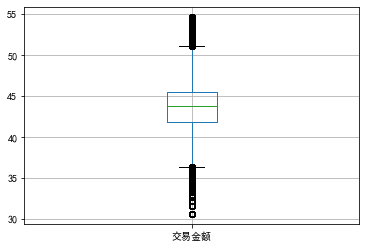

In [7]:
bank.boxplot("交易金额")
plt.show()

首先删掉交易金额小于 0 的数据
交易金额的平均值为：43.415926789739714，标准差为：3.0522622794206087


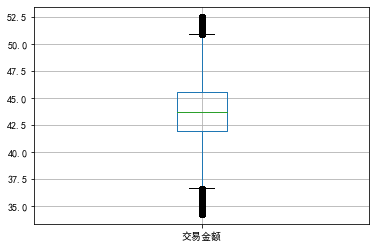

In [8]:
# 删掉交易金额小于 0 的数据
print("首先删掉交易金额小于 0 的数据")
neg_index = bank["交易金额"] < 0
bank = bank[~neg_index]
# 然后对这些数据进行正态分布拟合，求平均值和标准差
avg_val = np.average(bank["交易金额"])
std_val = np.std(bank["交易金额"])
print(f"交易金额的平均值为：{avg_val}，标准差为：{std_val}")
# 基于 3 sigma 原则，删除 [avg - 3 * std, avg + 3 * std] 外的数据
upper_bound = avg_val + 3 * std_val
lower_bound = avg_val - 3 * std_val
drop_index = (bank["交易金额"] < lower_bound) | (bank["交易金额"] > upper_bound)
bank = bank[~drop_index]
# 来看看去异后箱线图
bank.boxplot("交易金额")
plt.show()

# 3.数据预处理 (编码与特征构造)

编码：对 userinfo.csv 中的序数特征进行序号编码，名义特征进行独热编码

In [9]:
from sklearn.preprocessing import OneHotEncoder
onehot_encoder = OneHotEncoder(sparse=False)

# 独热编码
userinfo0= pd.get_dummies(userinfo, columns=['性别','职业','婚姻状态','户口类型'])

# 序号编码
userinfo0['教育程度'] = userinfo['教育程度'].map({'未知':0,'初中及以下':1,'高中':2,'大专':3,'本科及以上':4})
userinfo0

,new_user_id,教育程度,性别_女,性别_未知,性别_男,职业_事业单位,职业_企业,职业_公职,职业_学生,职业_无业,...,婚姻状态_其他情况,婚姻状态_已婚,婚姻状态_未婚,婚姻状态_未知,婚姻状态_离异,户口类型_其他户口,户口类型_农业户口,户口类型_家庭户口,户口类型_未知,户口类型_集体户口
0,7259fe272934e0dc348092c37544a445,4,1,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
1,0c87f6b1f7e0350a35841ba34df9d26a,4,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,74c53a62f15cc039864aefc41170f81b,3,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0
3,211f56f356fa6ecc6334bb73e52c7b16,2,0,0,1,0,1,0,0,0,...,0,0,0,0,1,0,1,0,0,0
4,07b0d9ac7924424894141b2fecfa0ee0,4,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,6b8887024b4258aab9c7b655fd2a718f,4,0,0,1,0,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
9996,158dd40361cd883d37a30fc448cfa7da,3,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,1
9997,12fd60bba16cb55cdf3ca81d7d3326b5,4,1,0,0,0,0,1,0,0,...,0,0,0,0,1,1,0,0,0,0
9998,180232fd2d1db5512be0fe554e58405c,3,0,0,1,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,0


状态性特征构造：平均欠款金额、平均还款比率、平均工资收入、平均非工资收入

In [10]:
bill["欠款金额"] = bill["上期账单金额"] - bill["上期还款金额"]
agg_cormoney = bill.groupby("new_user_id")["欠款金额"].agg(["mean"])
agg_cormoney.columns = ["平均欠款金额"]
agg_cormoney.reset_index(inplace=True)
agg_cormoney

,new_user_id,平均欠款金额
0,0000a11bede26d01990cd7bf86a4ffed,1.595222
1,0001102f53f24a8952ed5b47f9564354,-1.647174
2,000228d848615f1320914e0cf6064d12,-24.352021
3,0003f283dfacd7100bba76d876cf94da,-3.289508
4,000fc975cf7a868719446414a5034eae,0.702195
...,...,...
9559,ffe67dcf29be13aaea8203c7e1f78e52,2.522025
9560,ffea401657d40332181dc2b2ef814553,-12.558038
9561,ffeac4580f594e7fc0d98f6ba53755e3,2.659800
9562,ffed832f763c51fe6d055eae506f9ebf,0.733552


In [11]:
bill["还款比例"] = bill["上期账单金额"] / bill["上期还款金额"]
agg_cormoney1 = bill.groupby("new_user_id")["还款比例"].agg(["mean"])
agg_cormoney1.columns = ["平均还款比例"]
agg_cormoney1.reset_index(inplace=True)
agg_cormoney1

,new_user_id,平均还款比例
0,0000a11bede26d01990cd7bf86a4ffed,1.032223
1,0001102f53f24a8952ed5b47f9564354,0.968705
2,000228d848615f1320914e0cf6064d12,0.520719
3,0003f283dfacd7100bba76d876cf94da,0.926490
4,000fc975cf7a868719446414a5034eae,1.014207
...,...,...
9559,ffe67dcf29be13aaea8203c7e1f78e52,1.090502
9560,ffea401657d40332181dc2b2ef814553,0.754112
9561,ffeac4580f594e7fc0d98f6ba53755e3,1.094908
9562,ffed832f763c51fe6d055eae506f9ebf,1.014792


In [12]:
avg_salary = bank[bank['工资收入标记'] == 1].groupby(['new_user_id'])["交易金额"].agg(["mean"])
avg_salary.columns = ["平均工资收入"]
avg_salary.reset_index(inplace=True)
avg_salary

,new_user_id,平均工资收入
0,00375b8a7a62da4f578f4f4464fc4228,44.964550
1,00872649357929f1f3d7fafbe484810b,46.415984
2,00e44c200eeb161df7d08ac1b79bd4a7,47.292812
3,02419b54629f540d3430e6ba8230aac4,45.600048
4,024c12c231362aa4206c001674abe30f,40.380961
...,...,...
549,fdfcea9217eac320f5d2e30a58f356fa,42.958105
550,fe000bc1c6325b6df010187cca665a1e,46.980840
551,fed554907bfead73a15b053ecec59e11,47.292812
552,fee3ee14f7b2e42e86746d19115ef14a,47.061820


In [13]:
avg_income = bank[bank['工资收入标记'] == 0].groupby(['new_user_id'])["交易金额"].agg(["mean"])
avg_income.columns = ["平均非工资收入"]
avg_income.reset_index(inplace=True)
avg_income

,new_user_id,平均非工资收入
0,0003f283dfacd7100bba76d876cf94da,41.896800
1,00284cf15ae27d1ddf4f93922cd7bcb5,46.005739
2,00375b8a7a62da4f578f4f4464fc4228,44.640747
3,0057bbe021e9c3fc79834e3ff126bb98,43.890076
4,00872649357929f1f3d7fafbe484810b,43.472006
...,...,...
1678,ff1d4165c6f00864249193f5e3de1670,43.778847
1679,ff2d236c45aae847d1a1694520fd38f9,42.351222
1680,ff4a7b68f9856efa64c341ada41adb84,45.572454
1681,ffc8a37173c1046de20b0f3b6286cd88,43.149652


趋势性特征构造：过去半年内工资增长趋势

In [14]:
def cust_period(value, op="days", op_period=0, base_dt=None):
    value_list = value.tolist()
    
    while "-1" in value_list:
        value_list.remove("-1")
    if len(value_list) != 0:
        if not base_dt:
            max_dt = max(value_list)
        else:
            max_dt = base_dt

        if op == "years":
            end_dt = (datetime.datetime.strptime(max_dt, "%Y-%m-%d %H:%M:%S") + relativedelta(years=-op_period)).strftime("%Y-%m-%d %H:%M:%S")
        elif op == "months":
            end_dt = (datetime.datetime.strptime(max_dt, "%Y-%m-%d %H:%M:%S") + relativedelta(months=-op_period)).strftime("%Y-%m-%d %H:%M:%S")
        elif op == "weeks":
            end_dt = (datetime.datetime.strptime(max_dt, "%Y-%m-%d %H:%M:%S") + relativedelta(weeks=-op_period)).strftime("%Y-%m-%d %H:%M:%S")
        elif op == "days":
            end_dt = (datetime.datetime.strptime(max_dt, "%Y-%m-%d %H:%M:%S") + relativedelta(days=-op_period)).strftime("%Y-%m-%d %H:%M:%S")
        else:
            print("Wrong operation unit of time!")
            exit()
        period = list(value.values >= end_dt)
        return period
    else:
        return [True]*len(value.tolist())


In [15]:
agg_agg_6m = bank[bank['工资收入标记'] == 1].groupby("new_user_id")["交易金额","交易时间"]
agg_agg_6m = agg_agg_6m.apply(lambda x: x[cust_period(x["交易时间"], "months", 6)])
agg_agg_6m = agg_agg_6m.groupby("new_user_id")["交易金额"].agg(["sum"])
agg_agg_6m.columns = ["6月内工资收入"]
agg_agg_6m.reset_index(inplace=True)
agg_agg_3m = bank[bank['工资收入标记'] == 1].groupby("new_user_id")["交易金额","交易时间"]
agg_agg_3m = agg_agg_3m.apply(lambda x: x[cust_period(x["交易时间"], "months", 3)])
agg_agg_3m = agg_agg_3m.groupby("new_user_id")["交易金额"].agg(["sum"])
agg_agg_3m.columns = ["3月内工资收入"]
agg_agg_3m.reset_index(inplace=True)
agg_tend_3m = pd.merge(agg_agg_6m, agg_agg_3m, how='left', on=['new_user_id'])
agg_tend_3m["半年到3月前工资收入"] = agg_tend_3m["6月内工资收入"] - agg_tend_3m['3月内工资收入']
def cal(x):
    if x['3月内工资收入'] >= x['半年到3月前工资收入']:
        return 1
    return 0
agg_tend_3m["过去半年内工资增长趋势"] = agg_tend_3m.apply(cal, axis=1)
agg_tend_3m

c:\Users\lenovo\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  """Entry point for launching an IPython kernel.
c:\Users\lenovo\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  


,new_user_id,6月内工资收入,3月内工资收入,半年到3月前工资收入,过去半年内工资增长趋势
0,00375b8a7a62da4f578f4f4464fc4228,179.858202,179.858202,0.000000,1
1,00872649357929f1f3d7fafbe484810b,232.079920,232.079920,0.000000,1
2,00e44c200eeb161df7d08ac1b79bd4a7,47.292812,47.292812,0.000000,1
3,02419b54629f540d3430e6ba8230aac4,723.807150,505.340387,218.466763,1
4,024c12c231362aa4206c001674abe30f,444.190576,240.997538,203.193037,1
...,...,...,...,...,...
549,fdfcea9217eac320f5d2e30a58f356fa,85.916210,85.916210,0.000000,1
550,fe000bc1c6325b6df010187cca665a1e,330.371292,187.340330,143.030962,1
551,fed554907bfead73a15b053ecec59e11,94.585625,94.585625,0.000000,1
552,fee3ee14f7b2e42e86746d19115ef14a,329.726555,235.289386,94.437169,1


统计性特征构造：过去半年内收入波动、交易行为的聚类特征

In [16]:
# 过去半年内收入波动
# 交易类型是 0 的为收入，1 是支出
in_train = bank[bank['交易类型'] == 1]
# 以月为单位统计标准差
agg_agg_tot = in_train.groupby("new_user_id")[['new_user_id']].agg('count')
agg_agg_tot.columns = ['None']
agg_agg_tot.reset_index(inplace=True)
agg_agg_tot = agg_agg_tot[['new_user_id']]
for i in range(1, 7):
    agg_agg_ins = in_train.groupby("new_user_id")["交易金额","交易时间"]
    agg_agg_ins = agg_agg_ins .apply(lambda x: x[cust_period(x["交易时间"], "months", i)])
    agg_agg_ins = agg_agg_ins.groupby("new_user_id")["交易金额"].agg(["sum"])
    agg_agg_ins.columns = [f"{i}月内收入"]
    agg_agg_ins.reset_index(inplace=True)
    agg_agg_tot = pd.merge(agg_agg_tot, agg_agg_ins, how='left', on=['new_user_id'])
for i in range(2, 7):
    agg_agg_tot[f'{i-1}到{i}月收入'] = agg_agg_tot[f"{i}月内收入"] - agg_agg_tot[f"{i-1}月内收入"]
agg_agg_tot[f'{0}到{1}月收入'] = agg_agg_tot[f"{1}月内收入"]
cols = [f'{i-1}到{i}月收入' for i in range(1, 7)]
agg_agg_tot['过去半年内收入波动'] = agg_agg_tot.apply(lambda x: np.std([x[c] for c in cols]), axis=1)
agg_agg_tot

c:\Users\lenovo\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  # Remove the CWD from sys.path while we load stuff.


,new_user_id,1月内收入,2月内收入,3月内收入,4月内收入,5月内收入,6月内收入,1到2月收入,2到3月收入,3到4月收入,4到5月收入,5到6月收入,0到1月收入,过去半年内收入波动
0,0003f283dfacd7100bba76d876cf94da,1370.029320,2077.131122,2409.089923,3188.894728,4111.918439,4570.785390,707.101802,331.958801,779.804805,923.023711,458.866951,1370.029320,335.604913
1,00284cf15ae27d1ddf4f93922cd7bcb5,12234.159757,23108.637713,40589.155590,60455.111834,60455.111834,60455.111834,10874.477957,17480.517877,19865.956244,0.000000,0.000000,12234.159757,7735.382997
2,00375b8a7a62da4f578f4f4464fc4228,6791.505674,9954.923321,9954.923321,10772.738636,10772.738636,11216.671980,3163.417647,0.000000,817.815315,0.000000,443.933344,6791.505674,2450.466084
3,0057bbe021e9c3fc79834e3ff126bb98,1131.440292,1836.303262,3327.108790,5238.269238,6419.212381,7321.210754,704.862970,1490.805528,1911.160448,1180.943143,901.998373,1131.440292,393.043172
4,00872649357929f1f3d7fafbe484810b,664.916185,1321.637488,1536.418315,1619.892389,1917.798447,1958.840734,656.721302,214.780827,83.474075,297.906057,41.042287,664.916185,250.804742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1678,ff1d4165c6f00864249193f5e3de1670,1834.708723,3065.651284,4760.137609,6007.137549,7359.088139,9265.644361,1230.942561,1694.486324,1246.999941,1351.950590,1906.556223,1834.708723,277.399000
1679,ff2d236c45aae847d1a1694520fd38f9,3486.877871,7369.729982,11648.963986,13747.163124,16880.385850,18645.966735,3882.852111,4279.234004,2098.199138,3133.222726,1765.580885,3486.877871,907.207775
1680,ff4a7b68f9856efa64c341ada41adb84,6323.172494,10831.302726,15530.609416,20212.676227,25161.096200,28906.102465,4508.130232,4699.306691,4682.066811,4948.419973,3745.006265,6323.172494,770.546751
1681,ffc8a37173c1046de20b0f3b6286cd88,5425.656374,7615.424959,11591.826976,19758.078976,25802.873100,28882.859547,2189.768585,3976.402016,8166.252000,6044.794123,3079.986448,5425.656374,1988.363433


In [17]:
# 交易行为的聚类特征
agg_agg_behavior = bank.groupby(["new_user_id", "交易类型"])["交易金额"].agg(["max", "min", "mean", "count", "sum"])
agg_agg_behavior.reset_index(inplace=True)
agg_agg_behavior_1 = agg_agg_behavior[agg_agg_behavior['交易类型']==1][["new_user_id", "max", "min", "mean", "count", "sum"]]
agg_agg_behavior_0 = agg_agg_behavior[agg_agg_behavior['交易类型']==0][["new_user_id", "max", "min", "mean", "count", "sum"]]
agg_agg_behavior_0.columns = ["new_user_id", "交易类型_0_交易金额_max", "交易类型_0_交易金额_min", "交易类型_0_交易金额_mean", "交易类型_0_交易金额_count", "交易类型_0_交易金额_sum"]
agg_agg_behavior_1.columns = ["new_user_id", "交易类型_1_交易金额_max", "交易类型_1_交易金额_min", "交易类型_1_交易金额_mean", "交易类型_1_交易金额_count", "交易类型_1_交易金额_sum"]
agg_agg_behavior_0,agg_agg_behavior_1

(                           new_user_id  交易类型_0_交易金额_max  交易类型_0_交易金额_min  \
 0     0003f283dfacd7100bba76d876cf94da        48.266228        35.308421   
 2     00284cf15ae27d1ddf4f93922cd7bcb5        49.442433        38.192380   
 4     00375b8a7a62da4f578f4f4464fc4228        50.060691        37.202054   
 6     0057bbe021e9c3fc79834e3ff126bb98        48.020046        36.128595   
 8     00872649357929f1f3d7fafbe484810b        47.502580        35.363689   
 ...                                ...              ...              ...   
 3355  ff1d4165c6f00864249193f5e3de1670        49.150646        36.500781   
 3357  ff2d236c45aae847d1a1694520fd38f9        48.736429        36.931687   
 3359  ff4a7b68f9856efa64c341ada41adb84        51.355072        36.217599   
 3361  ffc8a37173c1046de20b0f3b6286cd88        47.647217        35.965628   
 3363  ffea401657d40332181dc2b2ef814553        49.667581        34.375590   
 
       交易类型_0_交易金额_mean  交易类型_0_交易金额_count  交易类型_0_交易金额_sum  
 0          

通过逻辑回归（为了方便排版，移至分类模型处）选择最优特征进行训练

In [18]:
# 构造特征
df = pd.merge(userinfo0, overdue, on='new_user_id', how='left')
print(df.shape)
df = pd.merge(df, agg_cormoney, on='new_user_id', how='left')
df = pd.merge(df, agg_cormoney1, on='new_user_id', how='left')
df = pd.merge(df, avg_salary, on='new_user_id', how='left')
df = pd.merge(df, avg_income, on='new_user_id', how='left')
df = pd.merge(df, agg_tend_3m[['new_user_id', '过去半年内工资增长趋势']], on='new_user_id', how='left')
df = pd.merge(df, agg_agg_tot[['new_user_id', '过去半年内收入波动']], on='new_user_id', how='left')
df = pd.merge(df, agg_agg_behavior_0, on='new_user_id', how='left')
df = pd.merge(df, agg_agg_behavior_1, on='new_user_id', how='left')

# 转换分类型（Categorical）数据为对象（object）类型
for column in df.columns:
    if pd.api.types.is_categorical_dtype(df[column]):
        df[column] = df[column].astype('object')

# 填补空值
df = df.fillna(0)

df
print(df.shape)

(9997, 24)
(9997, 40)


In [19]:
# 定义特征列表
feat_0 = ['教育程度', '婚姻状态_已婚', '婚姻状态_未婚', '户口类型_农业户口', '户口类型_集体户口']
feat_1=['平均欠款金额','平均还款比例','平均工资收入','平均非工资收入']
feat_2=['过去半年内工资增长趋势','过去半年内收入波动']
feat_3=['交易类型_0_交易金额_mean','交易类型_1_交易金额_mean']
# 准备训练和测试数据
X = df[feat_0+feat_1+feat_2+feat_3]
Y_reg = df['分数']  # 回归标签
Y_clf = df['标签']  # 分类标签



In [45]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torch.optim as optim

# 数据转为 PyTorch 张量
# X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
X_tensor = torch.tensor(X.values, dtype=torch.float32) if isinstance(X, pd.DataFrame) else torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([9997, 13])

In [46]:
# 回归标签需为二维张量
y_reg_tensor = torch.tensor(Y_reg.values, dtype=torch.float32).unsqueeze(1)  
y_reg_tensor.shape

torch.Size([9997, 1])

In [47]:
# 分类标签为一维张量
y_cls_tensor = torch.tensor(Y_clf.values, dtype=torch.long) 
y_cls_tensor

tensor([0, 1, 1,  ..., 0, 1, 0])

In [48]:
# 定义全连接前馈神经网络回归模型
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super(RegressionNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.model(x)

In [49]:
# 定义全连接前馈神经网络分类模型
class ClassificationNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(ClassificationNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.model(x)

In [50]:
# 定义训练函数
def train(model, loader, criterion, optimizer, epochs=20, task="regression"):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch) if task == "regression" else criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(loader):.4f}")

In [51]:
# 定义测试函数
def evaluate(model, loader, task="regression"):
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            output = model(X_batch)
            pred = output if task == "regression" else torch.argmax(output, axis=1)
            predictions.extend(pred.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    return np.array(predictions), np.array(actuals)

In [52]:
#使用 KFold 进行交叉验证（回归任务）。
kf = KFold(n_splits=5, shuffle=True, random_state=42)
kf

KFold(n_splits=5, random_state=42, shuffle=True)

In [53]:
# 使用 StratifiedKFold 进行交叉验证（分类任务）。
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [54]:
# 保存回归任务的指标
reg_results = {"MSE": [], "R2": [], "PCC": []}

In [55]:
# 回归任务 - 5 折交叉验证
for fold, (train_idx, test_idx) in enumerate(kf.split(X_tensor)):
    train_data = DataLoader(TensorDataset(X_tensor[train_idx], y_reg_tensor[train_idx]), batch_size=32, shuffle=True)
    test_data = DataLoader(TensorDataset(X_tensor[test_idx], y_reg_tensor[test_idx]), batch_size=32, shuffle=False)

    reg_model = RegressionNN(input_dim=X_tensor.shape[1])
    reg_optimizer = optim.Adam(reg_model.parameters(), lr=0.001)
    reg_criterion = nn.MSELoss()

    # 训练回归模型
    print(f"\n--- 回归任务 - 第 {fold + 1} 折 ---")
    train(reg_model, train_data, reg_criterion, reg_optimizer, epochs=10, task="regression")

    # 测试回归模型
    y_pred, y_actual = evaluate(reg_model, test_data, task="regression")
    mse = mean_squared_error(y_actual, y_pred)
    r2 = r2_score(y_actual, y_pred)
    pcc = np.corrcoef(y_actual.ravel(), y_pred.ravel())[0, 1]

    reg_results["MSE"].append(mse)
    reg_results["R2"].append(r2)
    reg_results["PCC"].append(pcc)


--- 回归任务 - 第 1 折 ---
Epoch 1/10, Loss: 1639.6526
Epoch 2/10, Loss: 118.1519
Epoch 3/10, Loss: 60.1246
Epoch 4/10, Loss: 68.2456
Epoch 5/10, Loss: 26.6134
Epoch 6/10, Loss: 18.2489
Epoch 7/10, Loss: 16.7437
Epoch 8/10, Loss: 16.6383
Epoch 9/10, Loss: 14.1513
Epoch 10/10, Loss: 30.8760

--- 回归任务 - 第 2 折 ---
Epoch 1/10, Loss: 1955.3229
Epoch 2/10, Loss: 156.8754
Epoch 3/10, Loss: 77.9564
Epoch 4/10, Loss: 57.9794
Epoch 5/10, Loss: 45.5007
Epoch 6/10, Loss: 34.9888
Epoch 7/10, Loss: 31.1098
Epoch 8/10, Loss: 25.8233
Epoch 9/10, Loss: 27.5138
Epoch 10/10, Loss: 16.7107

--- 回归任务 - 第 3 折 ---
Epoch 1/10, Loss: 1578.7276
Epoch 2/10, Loss: 112.4019
Epoch 3/10, Loss: 65.2586
Epoch 4/10, Loss: 62.6375
Epoch 5/10, Loss: 36.8659
Epoch 6/10, Loss: 30.1617
Epoch 7/10, Loss: 24.2314
Epoch 8/10, Loss: 25.5827
Epoch 9/10, Loss: 18.1111
Epoch 10/10, Loss: 15.1660

--- 回归任务 - 第 4 折 ---
Epoch 1/10, Loss: 1475.7382
Epoch 2/10, Loss: 123.3185
Epoch 3/10, Loss: 69.5378
Epoch 4/10, Loss: 61.6006
Epoch 5/10, L

In [56]:
# 输出回归任务的平均结果
print(f"回归任务 - 平均 MSE: {np.mean(reg_results['MSE']):.4f}")
print(f"回归任务 - 平均 R2: {np.mean(reg_results['R2']):.4f}")
print(f"回归任务 - 平均 PCC: {np.mean(reg_results['PCC']):.4f}")

回归任务 - 平均 MSE: 15.6676
回归任务 - 平均 R2: 0.7662
回归任务 - 平均 PCC: 0.8855


In [57]:
# 保存分类任务的指标
cls_results = {"Accuracy": [], "F1-score": [], "Precision": [], "Sensitivity": [], "AUC": []}

In [58]:
# 分类任务 - 5 折交叉验证
for fold, (train_idx, test_idx) in enumerate(skf.split(X_tensor, y_cls_tensor)):
    train_data = DataLoader(TensorDataset(X_tensor[train_idx], y_cls_tensor[train_idx]), batch_size=32, shuffle=True)
    test_data = DataLoader(TensorDataset(X_tensor[test_idx], y_cls_tensor[test_idx]), batch_size=32, shuffle=False)

    cls_model = ClassificationNN(input_dim=X_tensor.shape[1], num_classes=len(torch.unique(y_cls_tensor)))
    cls_optimizer = optim.Adam(cls_model.parameters(), lr=0.001)
    cls_criterion = nn.CrossEntropyLoss()

    # 训练分类模型
    print(f"\n--- 分类任务 - 第 {fold + 1} 折 ---")
    train(cls_model, train_data, cls_criterion, cls_optimizer, epochs=10, task="classification")

    # 测试分类模型
    y_pred, y_actual = evaluate(cls_model, test_data, task="classification")
    acc = accuracy_score(y_actual, y_pred)
    f1 = f1_score(y_actual, y_pred)
    precision = precision_score(y_actual, y_pred)
    sensitivity = recall_score(y_actual, y_pred)
    y_prob = torch.softmax(cls_model(X_tensor[test_idx]), axis=1)[:, 1].detach().numpy()
    auc_score = roc_auc_score(y_actual, y_prob)

    cls_results["Accuracy"].append(acc)
    cls_results["F1-score"].append(f1)
    cls_results["Precision"].append(precision)
    cls_results["Sensitivity"].append(sensitivity)
    cls_results["AUC"].append(auc_score)


--- 分类任务 - 第 1 折 ---
Epoch 1/10, Loss: 0.6952
Epoch 2/10, Loss: 0.5683
Epoch 3/10, Loss: 0.5520
Epoch 4/10, Loss: 0.5206
Epoch 5/10, Loss: 0.5320
Epoch 6/10, Loss: 0.4952
Epoch 7/10, Loss: 0.5193
Epoch 8/10, Loss: 0.4947
Epoch 9/10, Loss: 0.4921
Epoch 10/10, Loss: 0.5023

--- 分类任务 - 第 2 折 ---
Epoch 1/10, Loss: 0.5820
Epoch 2/10, Loss: 0.5187
Epoch 3/10, Loss: 0.5115
Epoch 4/10, Loss: 0.4879
Epoch 5/10, Loss: 0.4844
Epoch 6/10, Loss: 0.4884
Epoch 7/10, Loss: 0.4840
Epoch 8/10, Loss: 0.4850
Epoch 9/10, Loss: 0.4837
Epoch 10/10, Loss: 0.4799

--- 分类任务 - 第 3 折 ---
Epoch 1/10, Loss: 0.6004
Epoch 2/10, Loss: 0.5202
Epoch 3/10, Loss: 0.5035
Epoch 4/10, Loss: 0.5165
Epoch 5/10, Loss: 0.5041
Epoch 6/10, Loss: 0.5070
Epoch 7/10, Loss: 0.5006
Epoch 8/10, Loss: 0.4871
Epoch 9/10, Loss: 0.4889
Epoch 10/10, Loss: 0.4816

--- 分类任务 - 第 4 折 ---
Epoch 1/10, Loss: 0.6842
Epoch 2/10, Loss: 0.6089
Epoch 3/10, Loss: 0.5554
Epoch 4/10, Loss: 0.5286
Epoch 5/10, Loss: 0.5352
Epoch 6/10, Loss: 0.5340
Epoch 7/1

In [59]:
# 输出分类任务的平均结果
print(f"分类任务 - 平均 Accuracy: {np.mean(cls_results['Accuracy']):.4f}")
print(f"分类任务 - 平均 F1-score: {np.mean(cls_results['F1-score']):.4f}")
print(f"分类任务 - 平均 Precision: {np.mean(cls_results['Precision']):.4f}")
print(f"分类任务 - 平均 Sensitivity: {np.mean(cls_results['Sensitivity']):.4f}")
print(f"分类任务 - 平均 AUC: {np.mean(cls_results['AUC']):.4f}")

分类任务 - 平均 Accuracy: 0.8114
分类任务 - 平均 F1-score: 0.5776
分类任务 - 平均 Precision: 0.7752
分类任务 - 平均 Sensitivity: 0.4605
分类任务 - 平均 AUC: 0.7467


In [60]:
# 手动指定第 1 折数据
fold = 0
train_idx, test_idx = list(kf.split(X_tensor))[fold]  # 手动获取第 1 折索引
train_data = DataLoader(TensorDataset(X_tensor[train_idx], y_reg_tensor[train_idx]), batch_size=32, shuffle=True)
test_data = DataLoader(TensorDataset(X_tensor[test_idx], y_reg_tensor[test_idx]), batch_size=32, shuffle=False)

In [61]:
# 获取模型真实值和预测值
y_pred, y_actual = evaluate(reg_model, test_data, task="regression")

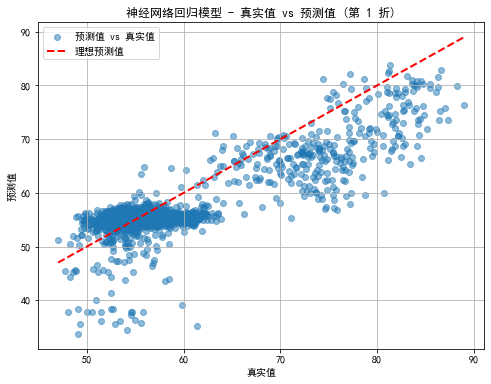

In [62]:
# 绘制散点图
plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred, alpha=0.5, label="预测值 vs 真实值")
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2, label="理想预测值")
plt.xlabel("真实值")
plt.ylabel("预测值")
plt.title("神经网络回归模型 - 真实值 vs 预测值 (第 1 折)")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
# 手动指定第 1 折数据
fold = 0
train_idx, test_idx = list(skf.split(X_tensor, y_cls_tensor))[fold]  # 手动获取第 1 折索引
train_data = DataLoader(TensorDataset(X_tensor[train_idx], y_cls_tensor[train_idx]), batch_size=32, shuffle=True)
test_data = DataLoader(TensorDataset(X_tensor[test_idx], y_cls_tensor[test_idx]), batch_size=32, shuffle=False)

In [64]:
# 获取并输出模型真实值和预测值
y_pred, y_actual = evaluate(cls_model, test_data, task="classification")
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [65]:
# 获取并输出模型预测概率
y_prob = torch.softmax(cls_model(X_tensor[test_idx]), axis=1)[:, 1].detach().numpy()  
y_prob

array([0.19905114, 0.15581237, 0.14921866, ..., 0.18804288, 0.21564661,
       0.23520692], dtype=float32)

In [66]:
# 计算 ROC 曲线
fpr, tpr, _ = roc_curve(y_actual, y_prob)

In [67]:
# 输出AUC得分
auc_score = roc_auc_score(y_actual, y_prob)

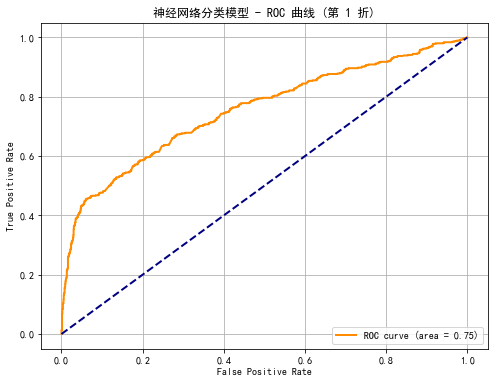

In [68]:
# 绘制 ROC 曲线
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("神经网络分类模型 - ROC 曲线 (第 1 折)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()